In [1]:
import pandas as pd
import seaborn as sns

# Load Titanic dataset exactly once
df = sns.load_dataset("titanic")

# Save the exact loaded dataset for offline use
df.to_csv("titanic.csv", index=False)

print("Titanic dataset loaded and saved successfully.")
print("Shape:", df.shape)

Titanic dataset loaded and saved successfully.
Shape: (891, 15)


In [2]:
print("DATASET INFO")
df.info()

print("\nDESCRIPTIVE STATISTICS")
display(df.describe(include="all"))

print("\nDATASET SHAPE")
print(df.shape)

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

DESCRIPTIVE STATISTICS


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



DATASET SHAPE
(891, 15)


In [3]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

print("MISSING VALUES SUMMARY")
display(missing_summary)

MISSING VALUES SUMMARY


,Missing Count,Missing Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


## Missing Value Handling Strategy

The Titanic dataset contains missing values in four columns:

- **Age:** 177 missing values (19.87%). Since the missing percentage is between 5% and 30%, missing ages will be **imputed**.
- **Embarked:** 2 missing values (0.22%). Since the missing percentage is below 5%, the corresponding rows will be **dropped**.
- **Deck:** 688 missing values (77.22%). Since the percentage is very high and reliable imputation would not be appropriate, the **deck column will be dropped**.
- **Embark_town:** 2 missing values (0.22%). Since the missing percentage is below 5%, the corresponding rows will be **dropped**.

These decisions follow the specified missing-value threshold rules.

In [4]:
# Make a copy so the original loaded dataset remains unchanged
df_clean = df.copy()

# 1. Drop the high-missingness column
df_clean = df_clean.drop(columns=["deck"])

# 2. Drop rows with <5% missing values
df_clean = df_clean.dropna(subset=["embarked", "embark_town"])

# 3. Impute age using the median
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

print("Shape after cleaning:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum())

Shape after cleaning: (889, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [5]:
# Verify that no missing values remain
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if remaining_missing.empty:
    print("No missing values remain.")
else:
    print("Remaining missing values:")
    print(remaining_missing)

No missing values remain.


## Univariate Analysis

Univariate analysis examines the distribution and potential outliers of individual numerical variables. The `age` and `fare` variables are analyzed using histograms, box plots, and the IQR outlier rule.

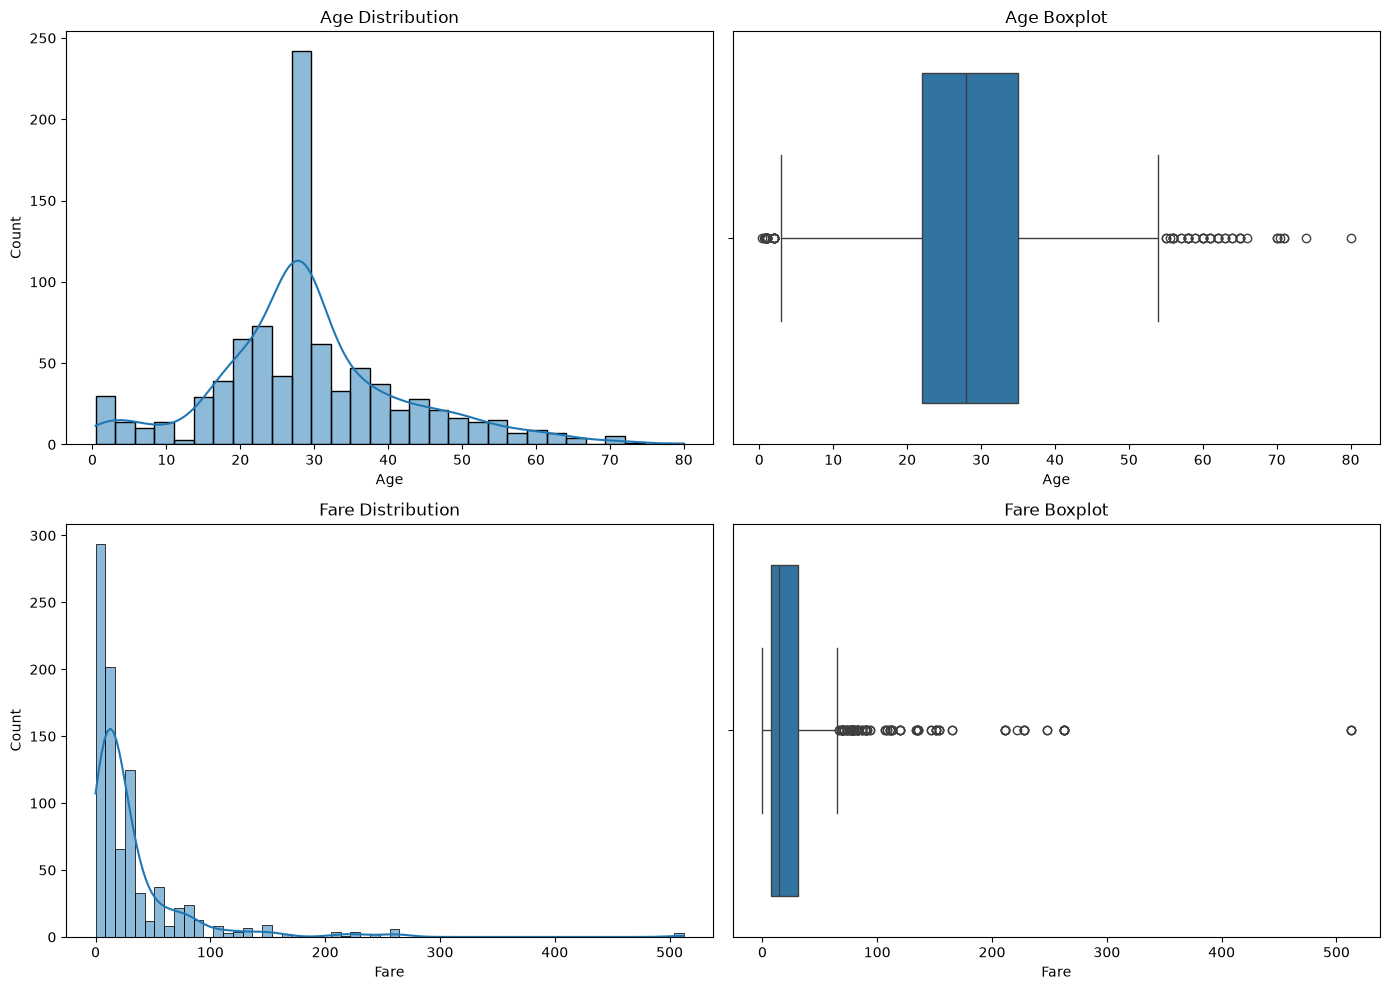

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create four plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age histogram
sns.histplot(df_clean["age"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")

# Age boxplot
sns.boxplot(x=df_clean["age"], ax=axes[0, 1])
axes[0, 1].set_title("Age Boxplot")
axes[0, 1].set_xlabel("Age")

# Fare histogram
sns.histplot(df_clean["fare"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Fare Distribution")
axes[1, 0].set_xlabel("Fare")

# Fare boxplot
sns.boxplot(x=df_clean["fare"], ax=axes[1, 1])
axes[1, 1].set_title("Fare Boxplot")
axes[1, 1].set_xlabel("Fare")

plt.tight_layout()
plt.show()

In [7]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return q1, q3, iqr, lower_bound, upper_bound, len(outliers)


age_results = iqr_outliers(df_clean["age"])
fare_results = iqr_outliers(df_clean["fare"])

print("AGE IQR ANALYSIS")
print("Q1:", age_results[0])
print("Q3:", age_results[1])
print("IQR:", age_results[2])
print("Lower Bound:", age_results[3])
print("Upper Bound:", age_results[4])
print("Outlier Count:", age_results[5])

print("\nFARE IQR ANALYSIS")
print("Q1:", fare_results[0])
print("Q3:", fare_results[1])
print("IQR:", fare_results[2])
print("Lower Bound:", fare_results[3])
print("Upper Bound:", fare_results[4])
print("Outlier Count:", fare_results[5])

AGE IQR ANALYSIS
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
Outlier Count: 65

FARE IQR ANALYSIS
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower Bound: -26.7605
Upper Bound: 65.6563
Outlier Count: 114


In [8]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

if fare_mean > fare_median > fare_mode:
    distribution = "Right-skewed"
elif fare_mean < fare_median < fare_mode:
    distribution = "Left-skewed"
else:
    distribution = "Approximately symmetric or not clearly classified by mean/median/mode ordering"

print("Fare Distribution:", distribution)


Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05
Fare Distribution: Right-skewed


### Univariate Analysis Interpretation

The age distribution is concentrated mainly between approximately 20 and 40 years. Using the IQR rule, 65 observations are identified as age outliers, with values outside the range 2.5 to 54.5 years.

The fare distribution is strongly right-skewed, with most passengers paying relatively low fares and a smaller number paying much higher fares. The IQR rule identifies 114 fare outliers above the upper bound of 65.6563. The fare mean (32.0967) is greater than the median (14.4542), which is greater than the mode (8.05), supporting the classification as right-skewed.

## Bivariate Analysis

Bivariate analysis examines relationships between two variables, including survival rates across passenger groups and correlations among selected numerical variables.

In [9]:
## Survival Rate Analysis

# Overall survival rate
overall_survival_rate = df_clean["survived"].mean() * 100

print(f"Overall survival rate: {overall_survival_rate:.2f}%")

# Survival rate by sex
survival_by_sex = (
    df_clean.groupby("sex", observed=True)["survived"]
    .mean()
    .mul(100)
    .reset_index(name="survival_rate")
)

print("\nSurvival Rate by Sex:")
display(survival_by_sex)

# Survival rate by passenger class
survival_by_pclass = (
    df_clean.groupby("pclass", observed=True)["survived"]
    .mean()
    .mul(100)
    .reset_index(name="survival_rate")
)

print("\nSurvival Rate by Passenger Class:")
display(survival_by_pclass)

# Survival rate by sex + passenger class
survival_by_sex_pclass = (
    df_clean.groupby(["sex", "pclass"], observed=True)["survived"]
    .mean()
    .mul(100)
    .reset_index(name="survival_rate")
)

print("\nSurvival Rate by Sex and Passenger Class:")
display(survival_by_sex_pclass)

Overall survival rate: 38.25%

Survival Rate by Sex:


,sex,survival_rate
0,female,74.038462
1,male,18.890815



Survival Rate by Passenger Class:


,pclass,survival_rate
0,1,62.616822
1,2,47.282609
2,3,24.236253



Survival Rate by Sex and Passenger Class:


,sex,pclass,survival_rate
0,female,1,96.739130
1,female,2,92.105263
2,female,3,50.000000
3,male,1,36.885246
4,male,2,15.740741
5,male,3,13.544669


In [10]:
## Boolean Masking Examples

# Female passengers in first class
female_first_class = df_clean[
    (df_clean["sex"] == "female") & 
    (df_clean["pclass"] == 1)
]

# Male passengers in third class
male_third_class = df_clean[
    (df_clean["sex"] == "male") & 
    (df_clean["pclass"] == 3)
]

# Passengers who were female OR in first class
female_or_first_class = df_clean[
    (df_clean["sex"] == "female") | 
    (df_clean["pclass"] == 1)
]

print("Female + First Class:", len(female_first_class))
print("Male + Third Class:", len(male_third_class))
print("Female OR First Class:", len(female_or_first_class))

Female + First Class: 92
Male + Third Class: 347
Female OR First Class: 434


In [11]:
## Correlation Matrix

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df_clean[correlation_columns].corr()

print("Correlation Matrix:")
display(corr_matrix)

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


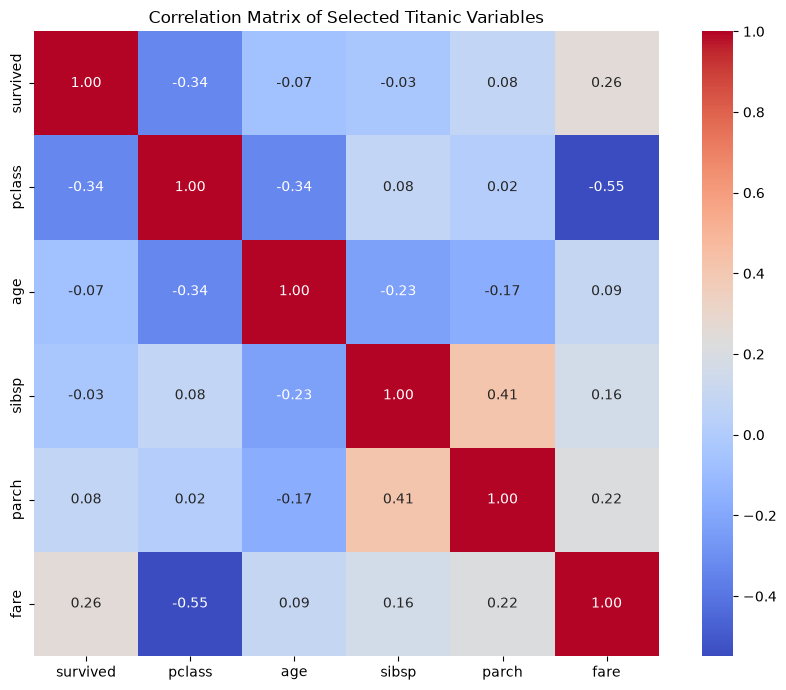

In [12]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of Selected Titanic Variables")
plt.tight_layout()
plt.show()

In [14]:
## Top 2 Strongest Correlations
import numpy as np
# Get only the upper triangle so each pair is counted once
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

correlations = (
    upper_triangle
    .stack()
    .abs()
    .sort_values(ascending=False)
)

print("Top 2 strongest correlations:")
display(correlations.head(2))

Top 2 strongest correlations:


pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64

### Bivariate Analysis Interpretation

The overall survival rate in the cleaned Titanic dataset is 38.25%. Survival differs substantially by sex: females had a survival rate of 74.04%, compared with 18.89% for males. Survival also decreases across passenger classes, from 62.62% in first class to 47.28% in second class and 24.24% in third class.

The combined sex and passenger-class analysis shows that female passengers had higher survival rates across all three classes, with the highest rate among first-class females at 96.74%. Male passengers had lower survival rates, particularly in second and third class, at 15.74% and 13.54% respectively.

The strongest absolute correlation is between `pclass` and `fare` (r = -0.5482), indicating a moderate negative relationship: higher numerical class values are associated with lower fares. The second strongest is between `sibsp` and `parch` (r = 0.4145), indicating a moderate positive relationship between the number of siblings/spouses and parents/children aboard.

# Multivariate Analysis

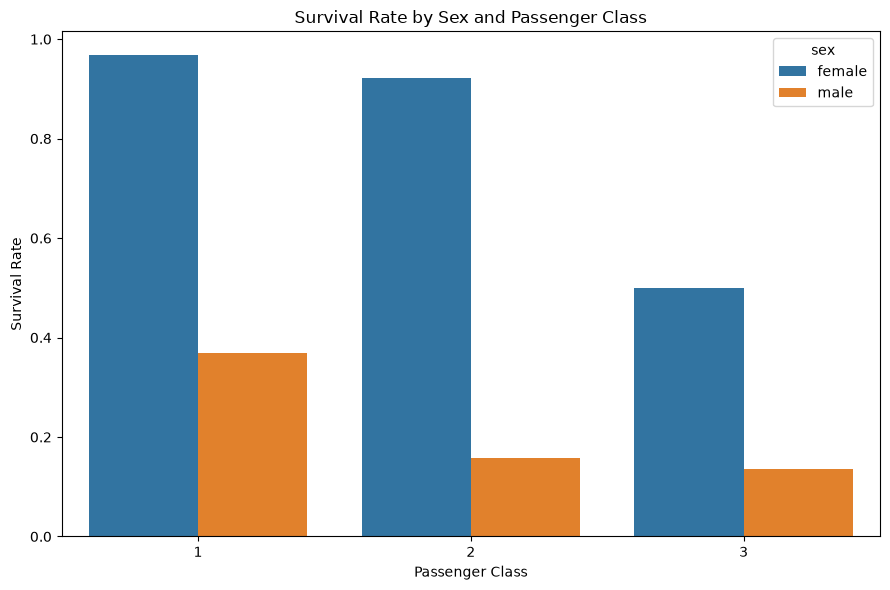

In [15]:
# Chart 1 — Survival by Sex and Passenger Class

plt.figure(figsize=(9, 6))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()

plt.savefig("outputs/multivariate_01_survival_sex_class.png", dpi=300)
plt.show()

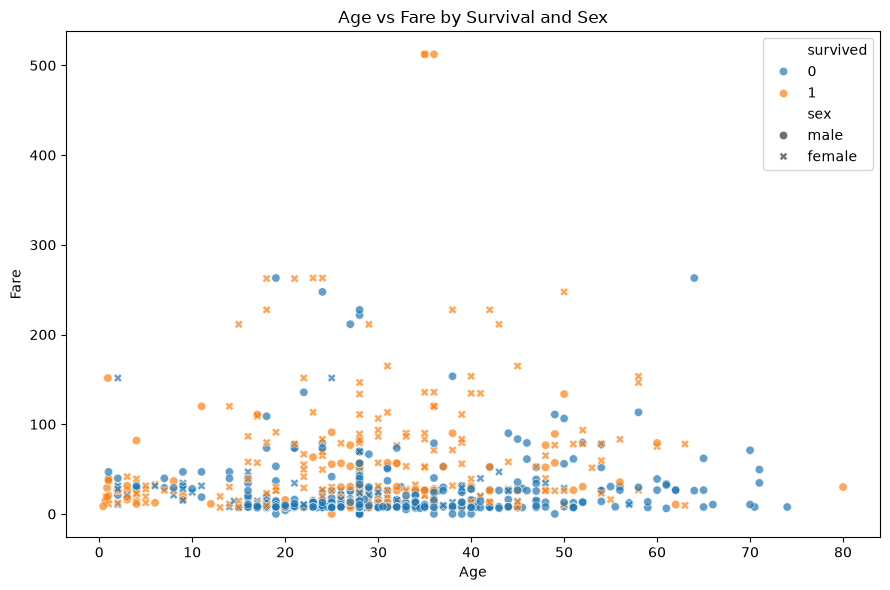

In [16]:
# Chart 2 — Age vs Fare by Survival
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title("Age vs Fare by Survival and Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()

plt.savefig("outputs/multivariate_02_age_fare_survival.png", dpi=300)
plt.show()

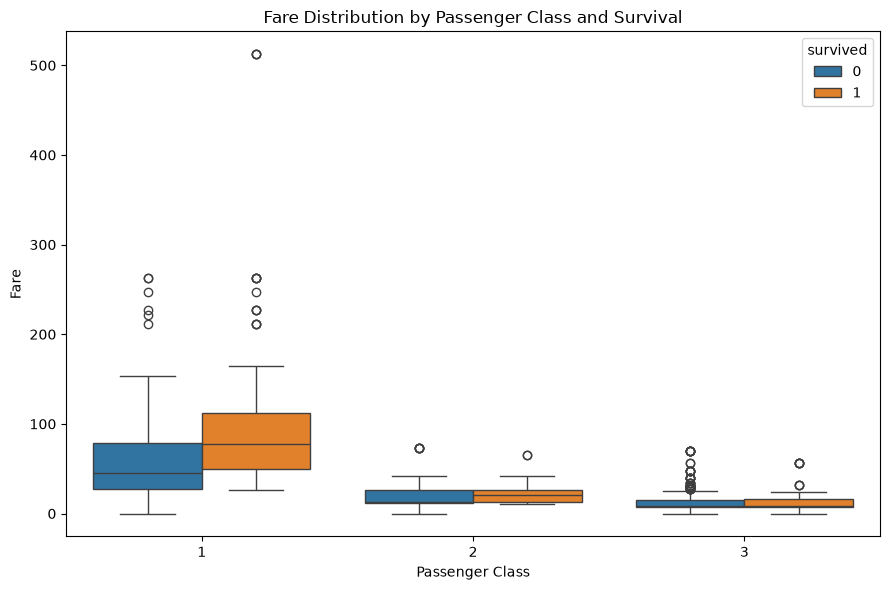

In [17]:
# Chart 3 — Fare by Passenger Class and Survival
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()

plt.savefig("outputs/multivariate_03_fare_class_survival.png", dpi=300)
plt.show()

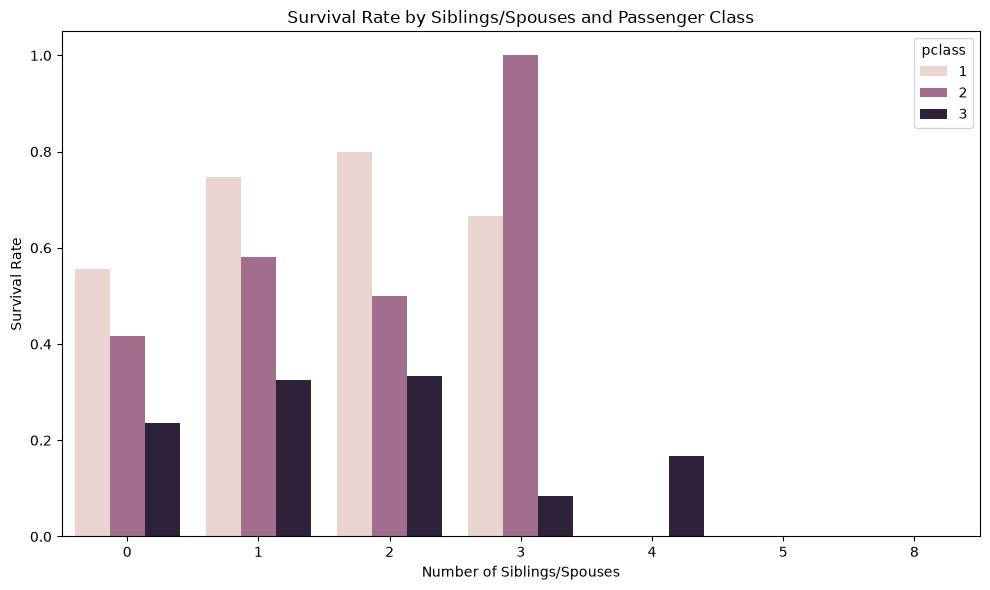

In [18]:
# Chart 4 — Family Relationship and Survival
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x="sibsp",
    y="survived",
    hue="pclass",
    errorbar=None
)

plt.title("Survival Rate by Siblings/Spouses and Passenger Class")
plt.xlabel("Number of Siblings/Spouses")
plt.ylabel("Survival Rate")
plt.tight_layout()

plt.savefig("outputs/multivariate_04_sibsp_class_survival.png", dpi=300)
plt.show()

### Multivariate Chart 1 — Survival by Sex and Passenger Class

Survival rates vary across both sex and passenger class. Female passengers show higher survival rates than male passengers within each class, while first-class passengers generally have higher survival than passengers in lower classes. This shows that sex and passenger class together provide useful context for understanding survival differences.

### Multivariate Chart 2 — Age, Fare and Survival

The scatter plot shows the relationship between passenger age and fare while distinguishing passengers by survival and sex. Fare values are concentrated at lower levels, while a smaller number of passengers paid substantially higher fares. The scatter plot shows the relationship between passenger age and fare while distinguishing passengers by survival and sex. Fare values are concentrated at lower levels, while a smaller number of passengers paid substantially higher fares. The plot also shows that survival status varies across different age and fare combinations, suggesting that age alone does not capture the observed survival pattern.

### Multivariate Chart 3 — Fare, Passenger Class and Survival

Fare distributions differ substantially between passenger classes, with higher fares generally associated with first-class passengers. The box plots also show substantial high-fare outliers. Survival status varies within each passenger class, demonstrating that fare and class provide additional context when examining survival.

### Multivariate Chart 4 — Siblings/Spouses, Class and Survival

Survival rates vary according to the number of siblings or spouses aboard and passenger class. Passenger class continues to distinguish survival patterns across different family-group sizes. The chart illustrates that survival is influenced by multiple interacting passenger characteristics rather than a single variable.

## EDA Standardization Sanity Check

To verify the effect of z-score standardization, `age` and `fare` are standardized using the formula `(x - mean) / standard deviation`. The standardized variables should have a mean approximately equal to 0 and a standard deviation approximately equal to 1.

This standardization is performed only as an EDA sanity check. The standardized data is not used directly for modeling; model preprocessing will be performed separately using a train-only preprocessing pipeline.

In [19]:
from sklearn.preprocessing import StandardScaler

# Select variables for EDA standardization
eda_features = df_clean[["age", "fare"]].copy()

# Statistics before standardization
print("Before Standardization:")
print(eda_features.agg(["mean", "std"]))

# Apply z-score standardization
scaler_eda = StandardScaler()
eda_standardized = scaler_eda.fit_transform(eda_features)

eda_standardized_df = pd.DataFrame(
    eda_standardized,
    columns=["age_standardized", "fare_standardized"],
    index=df_clean.index
)

# Statistics after standardization
print("\nAfter Standardization:")
print(eda_standardized_df.agg(["mean", "std"]))

Before Standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After Standardization:
      age_standardized  fare_standardized
mean      2.717486e-16       1.398706e-16
std       1.000563e+00       1.000563e+00


In [20]:
print("\nStandardization Check:")

print(
    "Age mean:",
    round(eda_standardized_df["age_standardized"].mean(), 10)
)
print(
    "Age std:",
    round(eda_standardized_df["age_standardized"].std(), 10)
)

print(
    "Fare mean:",
    round(eda_standardized_df["fare_standardized"].mean(), 10)
)
print(
    "Fare std:",
    round(eda_standardized_df["fare_standardized"].std(), 10)
)


Standardization Check:
Age mean: 0.0
Age std: 1.0005629046
Fare mean: 0.0
Fare std: 1.0005629046


### Standardization Interpretation

Before standardization, age had a mean of 29.3152 and fare had a mean of 32.0967. After z-score standardization, both variables had means effectively equal to 0 and standard deviations approximately equal to 1. This confirms that the standardization procedure worked correctly. This standardized data is used only for EDA validation and is not used directly in the modeling stage.